# When customers explicitly cancel: BTYD vs churn vs survival

In the BTYD notebook we said:

> If customers explicitly cancel, survival models or churn models may be a better first choice.

This notebook explains that statement deeply, with a synthetic subscription example.

We will compare three modeling mindsets:

| Model family | Best question | Typical data situation |
|---|---|---|
| BTYD / `lifetimes` | How many future repeat purchases will a non-contractual customer make? | Retail customers silently stop buying; no cancellation event exists. |
| Churn classifier | Will this active customer churn in a fixed future window? | Business wants a yes/no campaign target for next 30/60/90 days. |
| Survival model | When will this active customer churn, accounting for censoring? | Business cares about timing and not everyone has churned yet. |

The punchline will be visible in code: for a contractual subscription business, BTYD answers the wrong question and performs much worse as a churn-risk model.

## 1. The core distinction

A non-contractual retail customer can disappear without telling you. If they stop buying coffee, you do not know whether they are gone or just waiting until next month. That is where BTYD shines.

A contractual subscriber can explicitly cancel. You usually know the cancellation date. That changes the problem.

For subscriptions, monthly invoices are not spontaneous purchases. They are generated by the contract. A customer can look like a perfect repeat buyer until the day they cancel.

That is why BTYD can look technically valid but be strategically wrong.

**Two axes, four quadrants.** Fader and Hardie's taxonomy actually splits customer bases along two axes: contractual vs non-contractual, and continuous-time vs discrete-time transaction opportunities. This notebook lives in the contractual, continuous-time cell: subscribers are billed monthly but can cancel on any day. There is also a contractual, **discrete-time** quadrant — annual renewals where churn can only surface at anniversary points — whose natural tools are the shifted-Beta-Geometric (sBG) model, discrete-time hazard models, or a per-renewal logistic regression. We do not simulate that case here, but the model-matching logic is the same: pick the tool that matches when and how churn can be observed.

In [1]:
import warnings

# Silence only the noisy-but-harmless categories; anything else should surface.
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lifetimes import BetaGeoFitter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from lifelines import CoxPHFitter, KaplanMeierFitter

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

RANDOM_SEED = 20260704

## 2. Story: a SaaS company with explicit cancellations

Imagine a B2B SaaS company.

Every active customer receives a monthly invoice. Some customers eventually submit a cancellation request. At the prediction date, the customer success team wants to know:

> Which currently active customers are likely to cancel in the next 90 days?

We will generate synthetic data with features known at the prediction date:

- plan type
- annual contract flag
- seats
- monthly fee
- onboarding score
- last-30-day usage
- support tickets
- payment failures
- NPS-like score

These are exactly the kinds of signals a churn or survival model can use. BTYD, in its standard form, mostly sees invoice timing.

One clarification: in this simulation the `annual_contract` flag means an annual-commitment **discount** on a monthly-billed, cancel-anytime subscription — still the continuous-time contractual setting. It lowers the daily cancellation hazard; it does not create renewal-cycle churn concentrated at anniversary dates, which would be the discrete-time contractual quadrant described in Section 1.

In [2]:
def simulate_subscription_customers(n_customers=4500, seed=RANDOM_SEED):
    # Local generator so re-running this cell alone reproduces the same data.
    rng = np.random.default_rng(seed)

    landmark = pd.Timestamp("2025-01-01")
    study_end = pd.Timestamp("2025-12-31")
    signup_start = pd.Timestamp("2023-01-01")
    signup_end = pd.Timestamp("2024-10-01")

    signup_date = signup_start + pd.to_timedelta(
        rng.integers(0, (signup_end - signup_start).days, n_customers), unit="D"
    )
    plan = rng.choice(["Starter", "Growth", "Enterprise"], n_customers, p=[0.48, 0.38, 0.14])
    annual_contract = rng.binomial(1, 0.18 + 0.28 * (plan == "Enterprise") + 0.10 * (plan == "Growth"))
    seats = np.round(
        rng.lognormal(1.4 + 0.3 * (plan == "Growth") + 0.8 * (plan == "Enterprise"), 0.55)
    ).astype(int).clip(1, 250)
    monthly_fee = 29 + 35 * (plan == "Growth") + 180 * (plan == "Enterprise") + seats * rng.uniform(3, 9, n_customers)

    onboarding_score = (45 + 13 * (plan != "Starter") + 9 * annual_contract + rng.normal(0, 16, n_customers)).clip(0, 100)
    usage_last_30 = rng.poisson(
        np.maximum(1, 5 + 5 * (plan == "Growth") + 8 * (plan == "Enterprise") + 0.20 * onboarding_score - 3 * (annual_contract == 0))
    ).clip(0, 60)
    support_tickets_90 = rng.poisson(0.7 + 0.8 * (plan == "Starter") + 0.04 * np.maximum(seats - 15, 0))
    payment_failures_90 = rng.binomial(2, 0.035 + 0.06 * (plan == "Starter") + 0.03 * (annual_contract == 0))
    nps_score = (
        45 + 0.7 * onboarding_score + 0.5 * usage_last_30 - 7 * support_tickets_90 - 15 * payment_failures_90 + rng.normal(0, 18, n_customers)
    ).clip(0, 100)

    # Daily cancellation hazard. The signs are intentionally intuitive:
    # low usage, poor onboarding, support friction, and payment failures increase cancellation risk.
    log_rate = (
        -5.55
        + 0.85 * (plan == "Starter")
        - 0.45 * (plan == "Enterprise")
        - 0.60 * annual_contract
        - 0.022 * onboarding_score
        - 0.035 * usage_last_30
        + 0.28 * support_tickets_90
        + 0.72 * payment_failures_90
        - 0.011 * nps_score
        + 0.002 * np.minimum(monthly_fee, 500)
    )
    rate = np.exp(log_rate)
    theoretical_cancel_days = np.ceil(rng.exponential(1 / rate)).astype(float)
    max_observable_days = (study_end - signup_date).days
    event_observed = theoretical_cancel_days <= max_observable_days
    safe_cancel_days = np.minimum(theoretical_cancel_days, max_observable_days + 1).astype(int)
    cancel_date_raw = signup_date + pd.to_timedelta(safe_cancel_days, unit="D")
    cancel_date = pd.Series(cancel_date_raw).where(event_observed, pd.NaT)

    customers = pd.DataFrame(
        {
            "customer_id": [f"S{i:05d}" for i in range(n_customers)],
            "signup_date": signup_date,
            "plan": plan,
            "annual_contract": annual_contract,
            "seats": seats,
            "monthly_fee": monthly_fee.round(2),
            "onboarding_score": onboarding_score.round(1),
            "usage_last_30": usage_last_30,
            "support_tickets_90": support_tickets_90,
            "payment_failures_90": payment_failures_90,
            "nps_score": nps_score.round(1),
            "cancel_date": cancel_date,
            "event_observed_full_study": event_observed.astype(int),
        }
    )
    return customers, landmark, study_end

customers, landmark, study_end = simulate_subscription_customers()
customers.head()

,customer_id,signup_date,plan,annual_contract,seats,monthly_fee,onboarding_score,usage_last_30,support_tickets_90,payment_failures_90,nps_score,cancel_date,event_observed_full_study
0,S00000,2023-01-02,Growth,0,3,75.24,72.9,17,1,1,80.4,2025-12-27,1
1,S00001,2024-03-15,Starter,1,3,50.29,54.1,16,1,0,90.9,NaT,0
2,S00002,2023-08-31,Growth,0,8,115.85,80.9,31,0,0,100.0,NaT,0
3,S00003,2024-01-03,Enterprise,1,1,215.90,45.4,21,1,0,83.4,NaT,0
4,S00004,2023-05-25,Starter,0,5,47.05,58.5,12,3,0,55.3,NaT,0


In [3]:
# The 60-day tenure condition is a guard: it ensures every cohort member has at
# least two monthly invoices of pre-landmark history. With this simulator's signup
# window (ends 2024-10-01) it never actually binds, but it protects the cohort
# definition if the simulation window changes.
active = customers[
    (customers["signup_date"] < landmark - pd.Timedelta(days=60))
    & (customers["cancel_date"].isna() | (customers["cancel_date"] > landmark))
].copy()

active["event_after_landmark"] = active["cancel_date"].notna().astype(int)
active["time_from_landmark"] = np.where(
    active["cancel_date"].notna(),
    (active["cancel_date"] - landmark).dt.days,
    (study_end - landmark).days,
).clip(1)
active["churn_90d"] = (
    active["cancel_date"].notna() & (active["cancel_date"] <= landmark + pd.Timedelta(days=90))
).astype(int)

print(f"Prediction date: {landmark.date()}")
print(f"Study end:       {study_end.date()}")
print(f"Active customers at prediction date: {len(active):,}")
print(f"Cancel later during study: {active['event_after_landmark'].mean():.1%}")
print(f"Cancel within next 90 days: {active['churn_90d'].mean():.1%}")

active[["signup_date", "plan", "annual_contract", "usage_last_30", "support_tickets_90", "payment_failures_90", "cancel_date", "time_from_landmark", "churn_90d"]].head()

Prediction date: 2025-01-01
Study end:       2025-12-31
Active customers at prediction date: 3,111
Cancel later during study: 20.2%
Cancel within next 90 days: 5.9%


,signup_date,plan,annual_contract,usage_last_30,support_tickets_90,payment_failures_90,cancel_date,time_from_landmark,churn_90d
0,2023-01-02,Growth,0,17,1,1,2025-12-27,360.0,0
1,2024-03-15,Starter,1,16,1,0,NaT,364.0,0
2,2023-08-31,Growth,0,31,0,0,NaT,364.0,0
3,2024-01-03,Enterprise,1,21,1,0,NaT,364.0,0
4,2023-05-25,Starter,0,12,3,0,NaT,364.0,0


## 3. Build the mechanical invoice table

For a subscription company, invoices happen because the contract is active.

That is the key difference from non-contractual retail:

- Retail order: the customer decided to buy today.
- Subscription invoice: the billing system charged them because they had not canceled yet.

BTYD treats observed repeat purchases as behavioral purchase events. For subscriptions, those events are partly mechanical.

We generate invoices for **all** customers — including those who cancelled before the landmark date — from signup until cancellation or the landmark, whichever comes first. Keeping the pre-landmark cancellers matters: fitting BTYD only on surviving customers would bake survivorship bias into the model (we return to this pitfall below).

In [4]:
def generate_monthly_invoices(customers_df, landmark):
    """Monthly invoices for ALL customers, from signup until cancellation or the landmark.

    Customers who cancelled before the landmark keep their truncated invoice history.
    Billing only the survivors is exactly the survivorship mistake we want to avoid
    when fitting BTYD later.
    """
    rows = []
    for _, row in customers_df.iterrows():
        invoice_date = row["signup_date"]
        month_index = 0
        while invoice_date <= landmark and not (
            pd.notna(row["cancel_date"]) and invoice_date >= row["cancel_date"]
        ):
            rows.append(
                {
                    "customer_id": row["customer_id"],
                    "invoice_date": invoice_date,
                    "sales_value": row["monthly_fee"],
                }
            )
            month_index += 1
            invoice_date = row["signup_date"] + pd.DateOffset(months=month_index)
    return pd.DataFrame(rows)

invoices = generate_monthly_invoices(customers, landmark)
print(f"Customers with invoice history: {invoices['customer_id'].nunique():,} of {len(customers):,}")
print(invoices.shape)
invoices.head()

Customers with invoice history: 4,500 of 4,500
(50286, 3)


,customer_id,invoice_date,sales_value
0,S00000,2023-01-02,75.24
1,S00000,2023-02-02,75.24
2,S00000,2023-03-02,75.24
3,S00000,2023-04-02,75.24
4,S00000,2023-05-02,75.24


In [5]:
invoice_summary = invoices.groupby("customer_id").agg(
    first_invoice=("invoice_date", "min"),
    last_invoice=("invoice_date", "max"),
    invoice_count=("invoice_date", "count"),
    avg_invoice=("sales_value", "mean"),
).reset_index()
invoice_summary = invoice_summary.merge(active[["customer_id", "churn_90d"]], on="customer_id", how="left")
invoice_summary["cohort"] = np.select(
    [invoice_summary["churn_90d"].isna(), invoice_summary["churn_90d"].eq(1)],
    ["cancelled before landmark", "active, cancels within 90d"],
    default="active, no cancellation within 90d",
)
invoice_summary.groupby("cohort")[["invoice_count", "avg_invoice"]].mean().round(2)

,invoice_count,avg_invoice
cohort,,
"active, cancels within 90d",12.74,80.76
"active, no cancellation within 90d",13.37,117.60
cancelled before landmark,6.34,73.43


## 4. Train/test split

All models will be evaluated on the same held-out active customers.

The label for the churn classifier is fixed-horizon:

> Did the active customer cancel within 90 days after the landmark date?

The survival model uses more information:

> How many days after the landmark until cancellation, or until censoring at study end?

The BTYD baseline only sees pre-landmark invoice timing.

In [6]:
train_idx, test_idx = train_test_split(
    active.index,
    test_size=0.35,
    random_state=42,
    stratify=active["churn_90d"],
)
train = active.loc[train_idx].copy()
test = active.loc[test_idx].copy()

print("train:", train.shape, "90d churn rate:", round(train["churn_90d"].mean(), 3))
print("test: ", test.shape, "90d churn rate:", round(test["churn_90d"].mean(), 3))

train: (2022, 16) 90d churn rate: 0.059
test:  (1089, 16) 90d churn rate: 0.06


## 5. BTYD baseline with `lifetimes`

We deliberately use BTYD as a baseline so we can see why it is the wrong first tool here.

BG/NBD is fit on the pre-landmark invoice histories of the **entire customer base**, including customers who already cancelled before the landmark (their billing streams simply stop early — that truncation is the only "death" signal the model can learn from). The held-out evaluation customers are excluded from fitting. The model never sees explicit cancellation dates as labels, nor any customer health features.

We then score the held-out **active** customers at the landmark. Because every one of them has recent, regular invoices, the model concludes they are all very likely alive.

In [7]:
def build_subscription_rfm(invoice_df, observation_end):
    grouped = invoice_df.groupby("customer_id").agg(
        first_invoice=("invoice_date", "min"),
        last_invoice=("invoice_date", "max"),
        invoice_count=("invoice_date", "count"),
        monetary_value=("sales_value", "mean"),
    )
    rfm = pd.DataFrame(index=grouped.index)
    rfm["frequency"] = (grouped["invoice_count"] - 1).astype(float)
    rfm["recency"] = (grouped["last_invoice"] - grouped["first_invoice"]).dt.days.astype(float)
    # Defensive guard: with a single invoice, last == first so recency is already 0;
    # this line just makes the lifetimes zero-repeat convention explicit.
    rfm.loc[rfm["frequency"].eq(0), "recency"] = 0.0
    rfm["T"] = (observation_end - grouped["first_invoice"]).dt.days.astype(float)
    rfm["monetary_value"] = grouped["monetary_value"].astype(float)
    if not (rfm["recency"] <= rfm["T"]).all():
        raise ValueError("RFM definition error: recency must be <= T")
    return rfm

rfm_observation_end = landmark + pd.Timedelta(days=1)

# Fit on the FULL pre-landmark billing history: the training-cohort actives PLUS every
# customer who cancelled before the landmark. The truncated streams of past cancellers
# are the only signal that lets BG/NBD estimate a non-zero dropout rate.
# Held-out evaluation customers stay out of the fit.
btyd_train_ids = set(customers["customer_id"]) - set(test["customer_id"])
train_invoices = invoices[invoices["customer_id"].isin(btyd_train_ids)]
rfm_train = build_subscription_rfm(train_invoices, rfm_observation_end)
rfm_all = build_subscription_rfm(invoices, rfm_observation_end)

bgf = BetaGeoFitter(penalizer_coef=0.1)
bgf.fit(rfm_train["frequency"], rfm_train["recency"], rfm_train["T"])
print("Fitted BG/NBD parameters (a is the dropout-probability parameter):")
print(bgf.summary["coef"].round(4))

rfm_test = rfm_all.loc[test["customer_id"]]
btyd_p_alive = bgf.conditional_probability_alive(rfm_test["frequency"], rfm_test["recency"], rfm_test["T"])
btyd_expected_invoices_90d = bgf.conditional_expected_number_of_purchases_up_to_time(
    90,
    rfm_test["frequency"],
    rfm_test["recency"],
    rfm_test["T"],
)

btyd_eval = test[["customer_id", "churn_90d"]].copy()
btyd_eval["btyd_p_alive"] = np.asarray(btyd_p_alive)
btyd_eval["btyd_expected_invoices_90d"] = np.asarray(btyd_expected_invoices_90d)
btyd_eval.head()

Fitted BG/NBD parameters (a is the dropout-probability parameter):
r         1.2563
alpha    45.0254
a         0.0663
b         0.5399
Name: coef, dtype: float64


,customer_id,churn_90d,btyd_p_alive,btyd_expected_invoices_90d
3256,S03256,0,0.993766,2.809769
3484,S03484,0,0.996152,2.878251
516,S00516,0,0.989465,2.741014
4110,S04110,0,0.996551,2.888803
3405,S03405,0,0.988623,2.759035


In [8]:
print("BTYD P(alive) distribution")
display(btyd_eval["btyd_p_alive"].describe().round(4).to_frame())
print("BTYD expected invoice count in next 90 days")
display(btyd_eval["btyd_expected_invoices_90d"].describe().round(4).to_frame())

btyd_auc_palive = roc_auc_score(btyd_eval["churn_90d"], 1 - btyd_eval["btyd_p_alive"])
btyd_auc_expected = roc_auc_score(btyd_eval["churn_90d"], -btyd_eval["btyd_expected_invoices_90d"])
print(f"BTYD AUC using 1 - P(alive): {btyd_auc_palive:.3f}")
print(f"BTYD AUC using -expected invoices: {btyd_auc_expected:.3f}")

BTYD P(alive) distribution


,btyd_p_alive
count,1089.0000
mean,0.9861
std,0.0104
min,0.9411
25%,0.9827
50%,0.9898
75%,0.9932
max,0.9971


BTYD expected invoice count in next 90 days


,btyd_expected_invoices_90d
count,1089.0000
mean,2.6937
std,0.1564
min,2.1131
25%,2.6201
50%,2.7397
75%,2.8050
max,2.9054


BTYD AUC using 1 - P(alive): 0.554
BTYD AUC using -expected invoices: 0.555


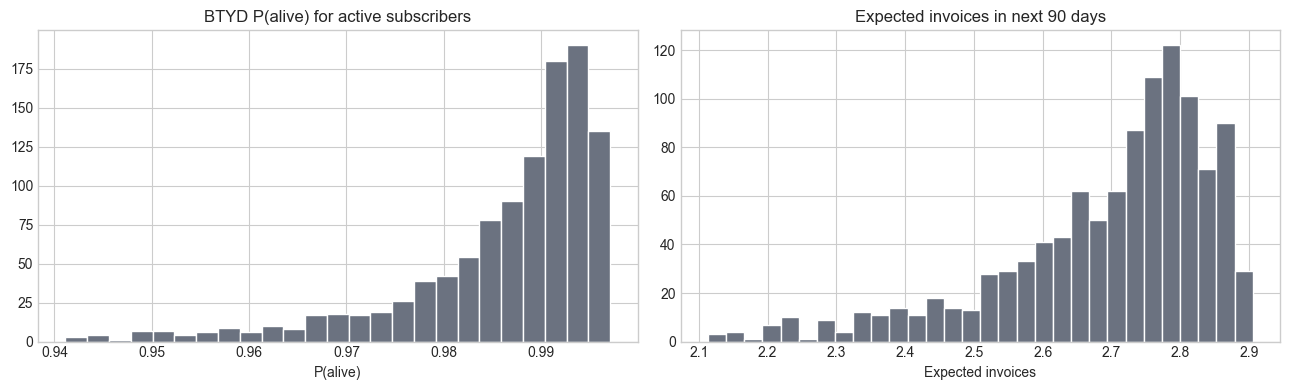

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(btyd_eval["btyd_p_alive"], bins=25, color="#6B7280", edgecolor="white")
axes[0].set_title("BTYD P(alive) for active subscribers")
axes[0].set_xlabel("P(alive)")
axes[1].hist(btyd_eval["btyd_expected_invoices_90d"], bins=30, color="#6B7280", edgecolor="white")
axes[1].set_title("Expected invoices in next 90 days")
axes[1].set_xlabel("Expected invoices")
plt.tight_layout()
plt.show()

## What just happened?

BG/NBD had *some* dropout signal to work with this time: customers who cancelled before the landmark left truncated invoice streams, so the fitted dropout parameter is small but non-zero (a ≈ 0.066). Even so, two things keep P(alive) from being a useful churn-risk score here:

1. **Cancellations are observed events, not silences.** BTYD's latent-death machinery exists to infer an unobserved "death" from a growing gap in an irregular purchase stream. Subscription invoices are mechanically regular while the contract is active and stop exactly at cancellation, so there is almost nothing for that machinery to grab onto.
2. **P(alive) compresses into a tiny range near 1 for active regular payers.** Everyone in the evaluation cohort is active at the landmark, with invoices running right up to the observation end. Their P(alive) values land in a narrow band (≈ 0.94–0.997 here) that carries almost no ranking signal about *future voluntary cancellation* — hence the near-chance AUC of 0.554.

**A classic pitfall worth naming:** if you make the mistake of fitting BG/NBD only on currently-active customers, the dropout parameter collapses to zero and P(alive) comes out exactly 1.0 for everyone — survivorship bias in the training data, not evidence.

The business question remains:

> Which active subscribers are about to submit an explicit cancellation request?

That requires customer health, usage, support, payment, and contract features.

## 6. Churn model: fixed-horizon cancellation risk

A churn classifier converts the question into a yes/no target:

> Will the customer cancel in the next 90 days?

This is often the right first model when the business needs a campaign list for a fixed window.

It does not model the full timing curve. It only models one horizon.

In [10]:
feature_cols = [
    "plan",
    "annual_contract",
    "seats",
    "monthly_fee",
    "onboarding_score",
    "usage_last_30",
    "support_tickets_90",
    "payment_failures_90",
    "nps_score",
]

X_train = pd.get_dummies(train[feature_cols], drop_first=True)
X_test = pd.get_dummies(test[feature_cols], drop_first=True).reindex(columns=X_train.columns, fill_value=0)
y_train = train["churn_90d"]
y_test = test["churn_90d"]

churn_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.04,
    max_leaf_nodes=15,
    l2_regularization=0.05,
    random_state=42,
)
churn_model.fit(X_train, y_train)
churn_proba = churn_model.predict_proba(X_test)[:, 1]

churn_auc = roc_auc_score(y_test, churn_proba)
churn_pr_auc = average_precision_score(y_test, churn_proba)
print(f"Churn classifier ROC-AUC: {churn_auc:.3f}")
print(f"Churn classifier PR-AUC:  {churn_pr_auc:.3f}")

Churn classifier ROC-AUC: 0.717
Churn classifier PR-AUC:  0.138


In [11]:
churn_eval = test[["customer_id", "plan", "usage_last_30", "support_tickets_90", "payment_failures_90", "churn_90d"]].copy()
churn_eval["churn_model_risk_90d"] = churn_proba
churn_eval.sort_values("churn_model_risk_90d", ascending=False).head(12).round(3)

,customer_id,plan,usage_last_30,support_tickets_90,payment_failures_90,churn_90d,churn_model_risk_90d
3418,S03418,Enterprise,12,1,1,0,0.717
933,S00933,Starter,9,1,1,0,0.710
1078,S01078,Starter,8,0,0,0,0.633
4476,S04476,Starter,6,0,0,1,0.558
4021,S04021,Starter,6,1,0,0,0.532
600,S00600,Starter,7,0,0,0,0.527
378,S00378,Starter,10,1,1,0,0.513
1317,S01317,Starter,9,1,1,0,0.486
4493,S04493,Starter,6,1,1,1,0.459
3599,S03599,Starter,11,3,0,0,0.451


## 7. Survival model: time-to-cancel with censoring

A survival model keeps the clock.

For every active customer at the landmark date, we define:

- `time_from_landmark`: days until cancellation, or days until study end if still active.
- `event_after_landmark`: 1 if cancellation was observed, 0 if censored.

This lets us estimate probabilities for many horizons:

- churn by 30 days
- churn by 90 days
- churn by 180 days
- expected retention curve

That is the key difference from a churn classifier.

A note on reading the Cox summary below: the model is fit with a small ridge penalty (`penalizer=0.05`), and Wald p-values are not valid inference under ridge shrinkage — so we sort coefficients by absolute magnitude and omit the p-value column.

In [12]:
cox_train = pd.concat(
    [X_train.reset_index(drop=True), train[["time_from_landmark", "event_after_landmark"]].reset_index(drop=True)],
    axis=1,
)
cox_test = pd.concat(
    [X_test.reset_index(drop=True), test[["time_from_landmark", "event_after_landmark"]].reset_index(drop=True)],
    axis=1,
)

cph = CoxPHFitter(penalizer=0.05)
cph.fit(cox_train, duration_col="time_from_landmark", event_col="event_after_landmark")

cox_cindex = cph.score(cox_test, scoring_method="concordance_index")
cox_churn_90d = 1 - cph.predict_survival_function(X_test, times=[90]).T[90]
cox_horizon_auc = roc_auc_score(y_test, cox_churn_90d)

print(f"Cox survival test concordance: {cox_cindex:.3f}")
print(f"Cox-derived 90-day churn ROC-AUC: {cox_horizon_auc:.3f}")
# Wald p-values are not valid under ridge shrinkage (penalizer > 0), so we omit
# them and rank coefficients by absolute magnitude instead.
cox_summary = cph.summary[["coef", "exp(coef)"]].copy()
cox_summary.reindex(cox_summary["coef"].abs().sort_values(ascending=False).index).round(3).head(10)

Cox survival test concordance: 0.755
Cox-derived 90-day churn ROC-AUC: 0.796


,coef,exp(coef)
covariate,,
payment_failures_90,0.627,1.872
plan_Starter,0.421,1.524
annual_contract,-0.340,0.712
plan_Growth,-0.233,0.792
support_tickets_90,0.226,1.254
usage_last_30,-0.037,0.964
onboarding_score,-0.014,0.986
nps_score,-0.013,0.987
seats,0.002,1.002


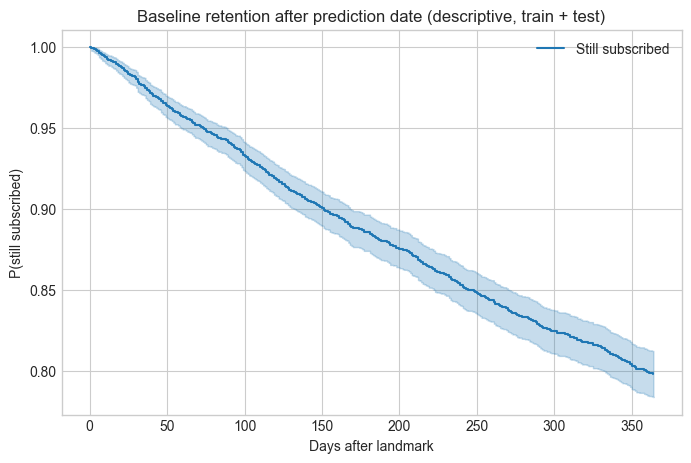

In [13]:
# Descriptive view of all active-at-landmark customers (train + test combined);
# this is not a held-out evaluation.
kmf = KaplanMeierFitter()
kmf.fit(active["time_from_landmark"], active["event_after_landmark"], label="Still subscribed")
ax = kmf.plot_survival_function(figsize=(8, 5))
ax.set_title("Baseline retention after prediction date (descriptive, train + test)")
ax.set_xlabel("Days after landmark")
ax.set_ylabel("P(still subscribed)")
plt.show()

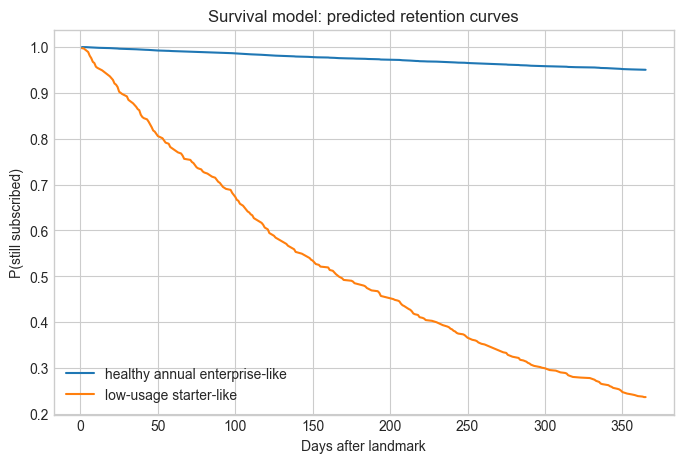

,profile,churn_by_30d,churn_by_90d,churn_by_180d
0,healthy annual enterprise-like,0.004,0.012,0.025
1,low-usage starter-like,0.108,0.296,0.518


In [14]:
low_risk = X_test.median().to_frame().T
high_risk = X_test.median().to_frame().T

# Build two illustrative profiles in the encoded feature space.
for col in X_test.columns:
    if col.startswith("plan_"):
        low_risk[col] = 0
        high_risk[col] = 0
if "plan_Enterprise" in X_test.columns:
    low_risk["plan_Enterprise"] = 1
if "plan_Starter" in X_test.columns:
    high_risk["plan_Starter"] = 1

low_risk["annual_contract"] = 1
low_risk["usage_last_30"] = X_test["usage_last_30"].quantile(0.85)
low_risk["support_tickets_90"] = 0
low_risk["payment_failures_90"] = 0
low_risk["onboarding_score"] = X_test["onboarding_score"].quantile(0.85)
low_risk["nps_score"] = X_test["nps_score"].quantile(0.85)

high_risk["annual_contract"] = 0
high_risk["usage_last_30"] = X_test["usage_last_30"].quantile(0.10)
high_risk["support_tickets_90"] = X_test["support_tickets_90"].quantile(0.90)
high_risk["payment_failures_90"] = 1
high_risk["onboarding_score"] = X_test["onboarding_score"].quantile(0.15)
high_risk["nps_score"] = X_test["nps_score"].quantile(0.15)

profiles = pd.concat([low_risk, high_risk], ignore_index=True)
profiles.index = ["healthy annual enterprise-like", "low-usage starter-like"]
curves = cph.predict_survival_function(profiles, times=np.arange(1, 366))
ax = curves.plot(figsize=(8, 5))
ax.set_title("Survival model: predicted retention curves")
ax.set_xlabel("Days after landmark")
ax.set_ylabel("P(still subscribed)")
plt.show()

pd.DataFrame(
    {
        "profile": profiles.index,
        "churn_by_30d": (1 - cph.predict_survival_function(profiles, times=[30]).T[30]).round(3).values,
        "churn_by_90d": (1 - cph.predict_survival_function(profiles, times=[90]).T[90]).round(3).values,
        "churn_by_180d": (1 - cph.predict_survival_function(profiles, times=[180]).T[180]).round(3).values,
    }
)

## 8. Head-to-head comparison

We evaluated all models on the same held-out active customers.

BTYD is represented by two possible churn-risk scores:

- `1 - P(alive)`: higher means more likely inactive.
- `-expected invoices`: lower expected invoice count means higher risk.

Neither is the right target in a contractual subscription setting.

We report a 95% bootstrap confidence interval (1,000 resamples of the test set) alongside each AUC. The Cox-vs-classifier gap (about 0.08 AUC) is within or near sampling noise — their 95% CIs overlap heavily — while the BTYD gap is not: the upper confidence limits of both BTYD scores sit below the point estimates of both feature-based models.

One honest disclosure about the deck-stacking: the simulator draws cancellation times from a constant-hazard model whose log-rate is linear in exactly the covariates we hand to the models, so the Cox model is correctly specified by design and the proportional-hazards assumption holds by construction. The AUC magnitudes are simulation artifacts; the qualitative gap between right-question and wrong-question models is the transferable lesson.

In [15]:
def bootstrap_auc_ci(y_true, scores, n_boot=1000, seed=RANDOM_SEED, alpha=0.05):
    """Percentile-bootstrap CI for ROC-AUC. A fixed seed reuses identical resamples across models."""
    y = np.asarray(y_true)
    s = np.asarray(scores, dtype=float)
    boot_rng = np.random.default_rng(seed)
    n = len(y)
    aucs = []
    for _ in range(n_boot):
        idx = boot_rng.integers(0, n, n)
        if y[idx].min() == y[idx].max():  # degenerate resample without both classes
            continue
        aucs.append(roc_auc_score(y[idx], s[idx]))
    lo, hi = np.percentile(aucs, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return lo, hi

# btyd_eval preserves the row order of `test`, so all four score vectors share the same
# label ordering and the same bootstrap resamples.
model_scores = {
    "BTYD: 1 - P(alive)": (btyd_eval["churn_90d"], 1 - btyd_eval["btyd_p_alive"]),
    "BTYD: -expected invoices 90d": (btyd_eval["churn_90d"], -btyd_eval["btyd_expected_invoices_90d"]),
    "Churn classifier: cancel within 90d": (y_test, churn_proba),
    "Survival model: 90d risk from Cox curve": (y_test, cox_churn_90d),
}

rows = []
for name, (y, s) in model_scores.items():
    lo, hi = bootstrap_auc_ci(y, s)
    rows.append(
        {
            "model": name,
            "test_roc_auc_for_90d_churn": roc_auc_score(y, s),
            "auc_95ci_low": lo,
            "auc_95ci_high": hi,
        }
    )

comparison = pd.DataFrame(rows).sort_values("test_roc_auc_for_90d_churn", ascending=False).reset_index(drop=True)
comparison_display = comparison.copy()
comparison_display["auc_95ci"] = comparison_display.apply(
    lambda r: f"[{r.auc_95ci_low:.3f}, {r.auc_95ci_high:.3f}]", axis=1
)
comparison_display[["model", "test_roc_auc_for_90d_churn", "auc_95ci"]].round(3)

,model,test_roc_auc_for_90d_churn,auc_95ci
0,Survival model: 90d risk from Cox curve,0.796,"[0.735, 0.850]"
1,Churn classifier: cancel within 90d,0.717,"[0.644, 0.784]"
2,BTYD: -expected invoices 90d,0.555,"[0.487, 0.626]"
3,BTYD: 1 - P(alive),0.554,"[0.483, 0.625]"


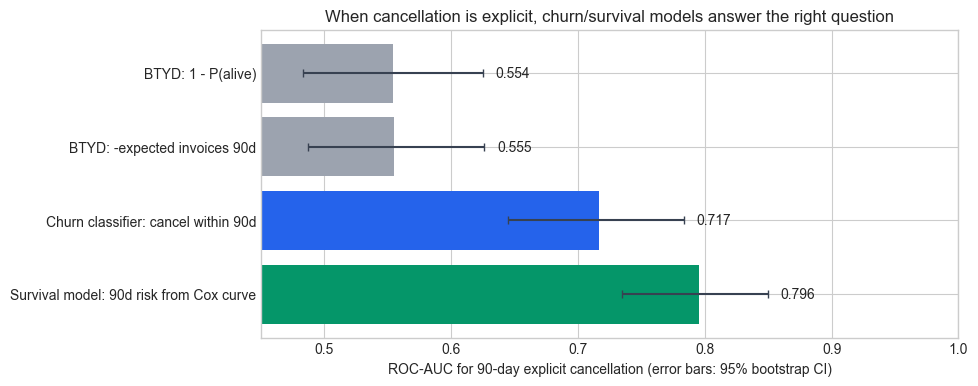

In [16]:
# Colors keyed by model name, not by row position, so re-sorting cannot mislabel bars.
model_colors = {
    "BTYD: 1 - P(alive)": "#9CA3AF",
    "BTYD: -expected invoices 90d": "#9CA3AF",
    "Churn classifier: cancel within 90d": "#2563EB",
    "Survival model: 90d risk from Cox curve": "#059669",
}

fig, ax = plt.subplots(figsize=(9, 4))
xerr = np.vstack(
    [
        comparison["test_roc_auc_for_90d_churn"] - comparison["auc_95ci_low"],
        comparison["auc_95ci_high"] - comparison["test_roc_auc_for_90d_churn"],
    ]
)
ax.barh(
    comparison["model"],
    comparison["test_roc_auc_for_90d_churn"],
    color=comparison["model"].map(model_colors),
    xerr=xerr,
    capsize=3,
    ecolor="#374151",
)
ax.set_xlim(0.45, 1.0)
ax.set_xlabel("ROC-AUC for 90-day explicit cancellation (error bars: 95% bootstrap CI)")
ax.set_title("When cancellation is explicit, churn/survival models answer the right question")
for i, (v, hi) in enumerate(zip(comparison["test_roc_auc_for_90d_churn"], comparison["auc_95ci_high"])):
    ax.text(hi + 0.01, i, f"{v:.3f}", va="center")
plt.show()

## 9. Churn model vs survival model

A churn classifier and a survival model are cousins, but they are not the same.

| Question | Churn classifier | Survival model |
|---|---|---|
| Target | Event before a fixed horizon | Time until event, plus censoring flag |
| Example | Cancel in next 90 days? | When will the customer cancel? |
| Output | One probability for one window | A full curve, so many horizons are possible |
| Censoring | Awkward unless horizon is fully observed | Native part of the model |
| Best for | Campaign targeting, simple operational lists | Retention curves, timing, multiple horizons, incomplete follow-up |

If the business says, "Give me a list for next month," a churn classifier is often enough.

If the business says, "How does risk evolve over time, and how many customers will remain subscribed at 30, 90, and 180 days?" use survival analysis.

## 10. Decision guide

Use this rule of thumb:

- **Use BTYD** when customers do not cancel and you only observe repeat purchase behavior.
- **Use a churn classifier** when you need a fixed-horizon probability such as `cancel in next 90 days`.
- **Use survival analysis** when timing and censoring matter, or when you need probabilities across multiple future horizons.
- **Use sBG or a discrete-time hazard / per-renewal logistic model** when contracts renew at fixed anniversary dates and churn is only observable at renewal points (the contractual, discrete-time quadrant from Section 1).

The crossover works in the other direction too: non-contractual churn can also be attacked with survival models by defining an operational inactivity window (for example, "no purchase within 90 days counts as churn") — which is exactly how this repository's Online Retail and Dunnhumby pipelines frame the problem.

For the synthetic subscription business, BTYD performed poorly because monthly invoices are not independent buying decisions. They are billing artifacts of an active contract.

The right target is explicit cancellation.

## Final consultant summary

A polished explanation to a stakeholder would be:

> BTYD is designed for non-contractual repeat purchase settings where churn is hidden. In our subscription business, churn is explicit: customers cancel. Because invoices are mechanically generated while the contract is active, standard BTYD mostly learns tenure and billing cadence. A churn classifier directly estimates cancellation within the campaign window, while a survival model estimates the full time-to-cancel curve and handles customers who have not canceled yet. For this use case, churn or survival should be the first modeling choice.

The modeling lesson is simple but important: choose the model that matches how the business observes the event.